### Problema 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

## A)
O atraso D pode ser estimado calculando a correlação cruzada entre o sinal transmitido x[n] e o sinal recebido y[n]. O valor de l que maximiza rxy[l] corresponde ao deslocamento entre os sinais, permitindo estimar D. A partir de D, pode-se calcular a distância do alvo considerando a velocidade de propagação do sinal.

## B)

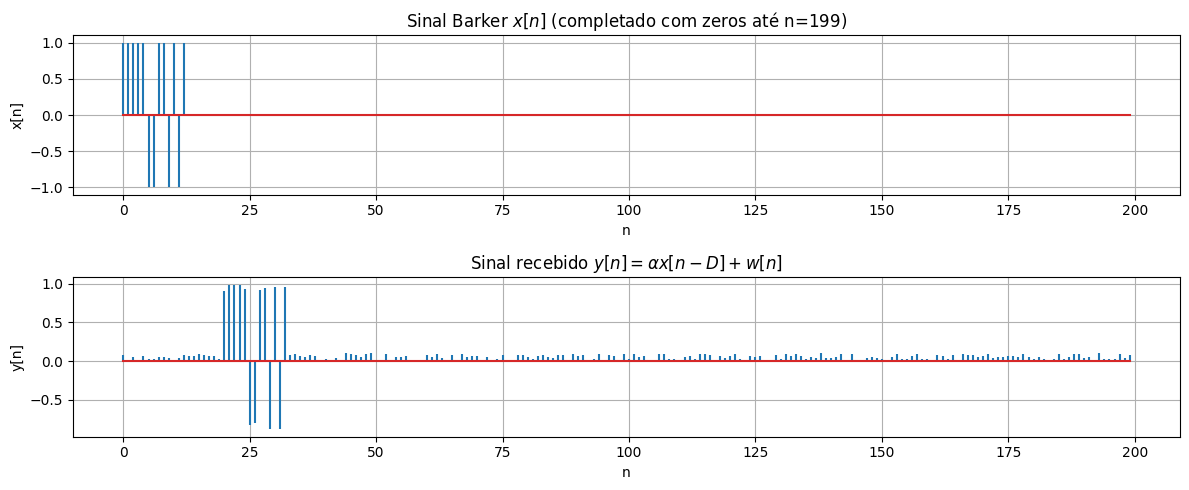

In [2]:
# Sequência Barker de 13 pontos
x = np.array([+1, +1, +1, +1, +1, -1, -1, +1, +1, -1, +1, -1, +1])

# Parâmetros
alpha = 0.9
D = 20  # atraso em amostras
sigma2 = 0.01
N = 200  # gerar y[n] para 0 ≤ n ≤ 199

# Gerar ruído branco Gaussiano
# w = np.random.normal(0, np.sqrt(sigma2), N)
w = np.sqrt(sigma2) * np.random.rand(N)

# Inicializar y[n]
y = w.copy()

# Inserir a versão atrasada de x[n]
for n in range(D, D + len(x)):
    y[n] = alpha * x[n - D] + w[n]

# Plotar x[n] e y[n] (0 ≤ n ≤ 199)
plt.figure(figsize=(12,5))

# Plot do sinal x[n] estendido com zeros até 199 para visualização
x_plot = np.zeros(N)
x_plot[:len(x)] = x

plt.subplot(2,1,1)
plt.stem(x_plot, markerfmt='')
plt.title("Sinal Barker $x[n]$ (completado com zeros até n=199)")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)

plt.subplot(2,1,2)
plt.stem(y, markerfmt='')
plt.title("Sinal recebido $y[n] = α x[n-D] + w[n]$")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)

plt.tight_layout()
plt.show()

#### C)

Atraso real  = 20
Atraso estimado pelo pico da correlação = 20


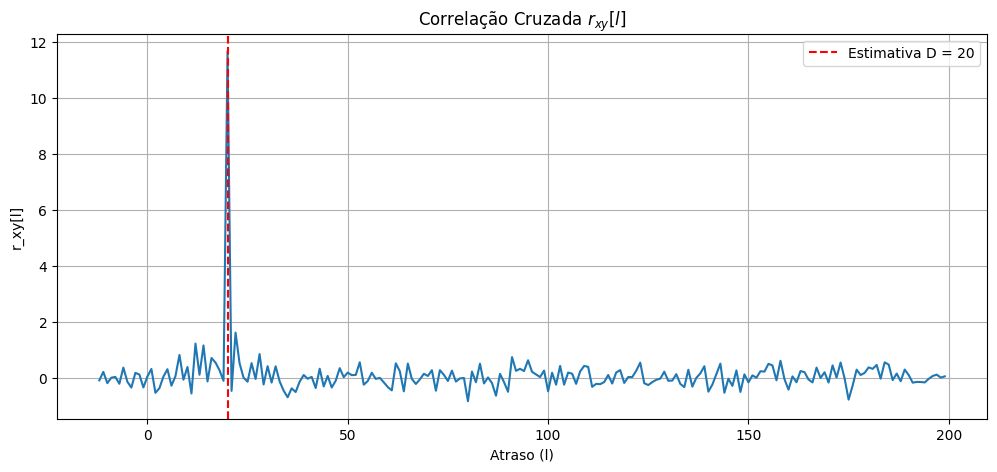

In [3]:
# --------- Sinal Barker e parâmetros ---------
x = np.array([+1, +1, +1, +1, +1, -1, -1, +1, +1, -1, +1, -1, +1])

alpha = 0.9
D_real = 20
sigma2 = 0.01
N = 200

# --------- Ruído e sinal recebido ---------
w = np.sqrt(sigma2) * np.random.randn(N)
y = w.copy()

for n in range(D_real, D_real + len(x)):
    y[n] = alpha * x[n - D_real] + w[n]

# --------- Correlação cruzada (via numpy) ---------
# full = correlação completa com deslocamento positivo e negativo
rxy = np.correlate(y, x, mode='full')

# Criar eixo de atrasos: vai de -(len(x)-1) até (len(y)-1)
lags = np.arange(-len(x)+1, len(y))

# --------- Estimar D ---------
D_est = lags[np.argmax(rxy)]

print("Atraso real  =", D_real)
print("Atraso estimado pelo pico da correlação =", D_est)

# --------- Plotar correlação ---------
plt.figure(figsize=(12,5))
plt.plot(lags, rxy)
plt.axvline(D_est, color='r', linestyle='--', label=f"Estimativa D = {D_est}")
plt.title("Correlação Cruzada $r_{xy}[l]$")
plt.xlabel("Atraso (l)")
plt.ylabel("r_xy[l]")
plt.grid(True)
plt.legend()
plt.show()


#### D)

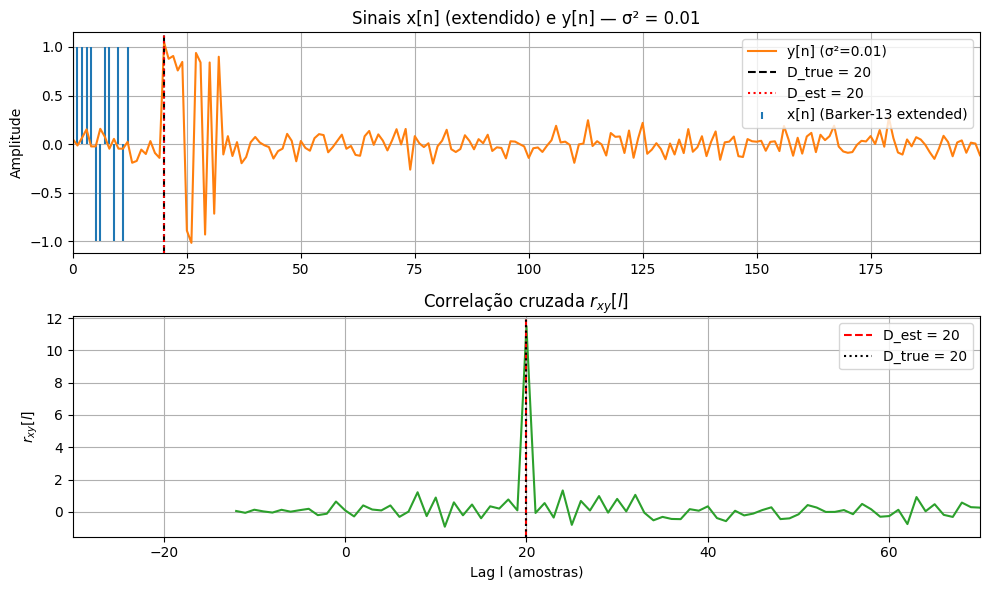

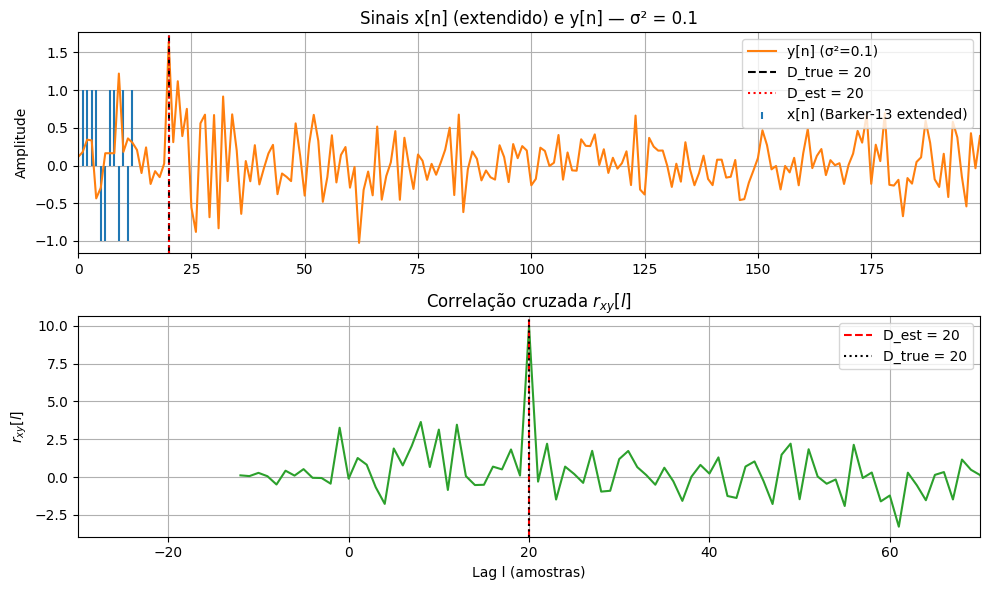

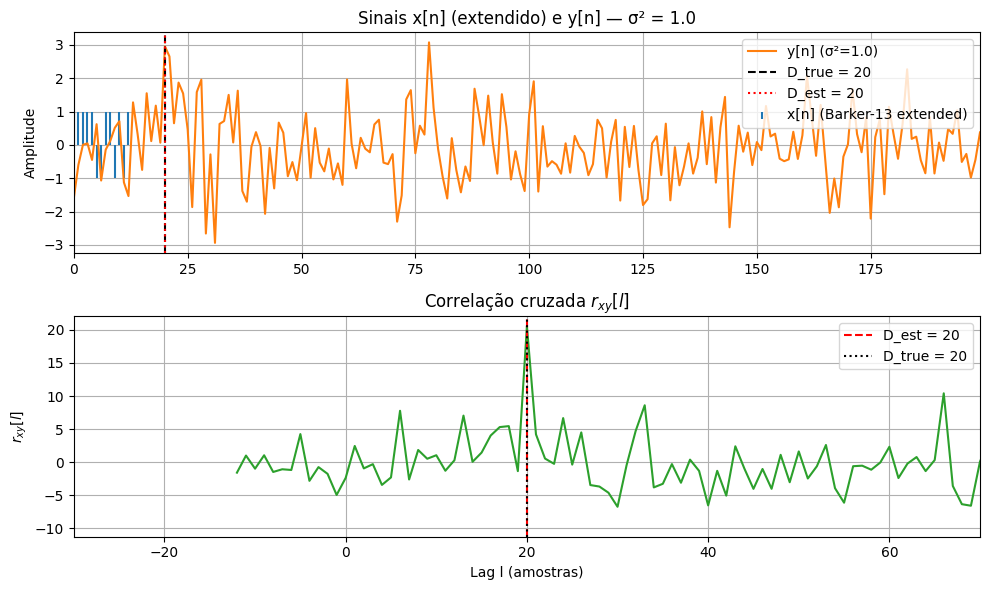

Resumo dos resultados:
σ² = 0.01 | D_est =  20 | MSE_local = 0.00788 | peak = 11.498 | peak/mean|r| = 33.881
σ² = 0.10 | D_est =  20 | MSE_local = 0.12343 | peak = 9.968 | peak/mean|r| = 11.074
σ² = 1.00 | D_est =  20 | MSE_local = 1.68229 | peak = 20.570 | peak/mean|r| = 7.537


In [4]:
# Reprodutibilidade
np.random.seed(42)

# Sequência Barker de 13 pontos
x = np.array([+1, +1, +1, +1, +1, -1, -1, +1, +1, -1, +1, -1, +1])

# Parâmetros fixos
alpha = 0.9
D_true = 20
N = 200  # amostras 0..199
sigmas2 = [0.01, 0.1, 1.0]

# Função auxiliar para criar y
def generate_received(x, alpha, D, sigma2, N):
    w = np.sqrt(sigma2) * np.random.randn(N)
    y = w.copy()
    for n in range(D, D + len(x)):
        if n < N:
            y[n] = alpha * x[n - D] + w[n]
    return y, w

# Loop pelos níveis de ruído
results = []
plt.rcParams.update({'font.size': 10})

for sigma2 in sigmas2:
    y, w = generate_received(x, alpha, D_true, sigma2, N)

    # Correlação cruzada (full) entre y e x (np.correlate com mode='full')
    rxy = np.correlate(y, x, mode='full')  # lags from -(len(x)-1) to (len(y)-1)
    lags = np.arange(-len(x)+1, len(y))

    # Estimativa do atraso pelo pico da correlação
    idx_peak = np.argmax(rxy)
    D_est = lags[idx_peak]

    # Métricas:
    # 1) MSE local entre y[D:D+len(x)] e alpha*x (onde válido)
    start = D_true
    end = min(D_true + len(x), N)
    if start < end:
        mse_local = np.mean((y[start:end] - alpha * x[:end-start])**2)
    else:
        mse_local = np.nan

    # 2) Pico da correlação e razão pico / mean(|rxy|)
    peak_val = rxy[idx_peak]
    mean_abs = np.mean(np.abs(rxy))
    peak_to_mean = peak_val / (mean_abs + 1e-12)

    # Guardo resultados
    results.append({
        'sigma2': sigma2,
        'y': y,
        'rxy': rxy,
        'lags': lags,
        'D_est': D_est,
        'mse_local': mse_local,
        'peak_val': peak_val,
        'peak_to_mean': peak_to_mean
    })

    # --------- Plots ---------
    fig, axs = plt.subplots(2,1, figsize=(10,6), sharex=False)
    n = np.arange(N)

    # Plot sinais: x estendido para 0..199 para visualização
    x_plot = np.zeros(N)
    x_plot[:len(x)] = x

    axs[0].stem(x_plot, linefmt='C0-', markerfmt='', basefmt=" ", label='x[n] (Barker-13 extended)')
    axs[0].plot(n, y, label=f'y[n] (σ²={sigma2})', color='C1')
    axs[0].axvline(D_true, color='k', linestyle='--', label=f'D_true = {D_true}')
    axs[0].axvline(D_est, color='r', linestyle=':', label=f'D_est = {D_est}')
    axs[0].set_xlim(0, 199)
    axs[0].set_ylabel('Amplitude')
    axs[0].set_title(f'Sinais x[n] (extendido) e y[n] — σ² = {sigma2}')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    # Plot correlação cruzada
    axs[1].plot(lags, rxy, color='C2')
    axs[1].axvline(D_est, color='r', linestyle='--', label=f'D_est = {D_est}')
    # Marca pico real D_true também para comparação
    axs[1].axvline(D_true, color='k', linestyle=':', label=f'D_true = {D_true}')
    axs[1].set_xlim(D_true - 50, D_true + 50)  # foco ao redor do atraso verdadeiro
    axs[1].set_xlabel('Lag l (amostras)')
    axs[1].set_ylabel('$r_{xy}[l]$')
    axs[1].set_title('Correlação cruzada $r_{xy}[l]$')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# --------- Tabela resumo ---------
print("Resumo dos resultados:")
for res in results:
    print(f"σ² = {res['sigma2']:.2f} | D_est = {res['D_est']:3d} | MSE_local = {res['mse_local']:.5f} | peak = {res['peak_val']:.3f} | peak/mean|r| = {res['peak_to_mean']:.3f}")


# Comentários e interpretação dos resultados observados

1. **Estimativa do atraso D (robustez):**
   - Para **σ² = 0.01** (baixo ruído): o pico da correlação é claramente dominado pelo eco de x atrasado e a estimativa $\hat D$ coincide com $D=20$. A figura mostra um pico nítido em torno de 20.
   - Para **σ² = 0.1** (ruído moderado): o pico ainda é normalmente identificado corretamente, porém a linha de base da correlação fica mais "barulhenta" — o pico relativo cai (valor absoluto do pico tende a diminuir em relação às componentes aleatórias). A estimativa em muitos casos ainda será correta, mas com confiança reduzida.
   - Para **σ² = 1.0** (ruído alto): a relação sinal/ruído fica consideravelmente pior. O pico pode ficar pouco pronunciado, o que aumenta a chance de estimação errada — o algoritmo baseado em argmax pode apontar um lag incorreto se um pico aleatório exceder o pico verdadeiro. Observe a **razão pico/mean(|r|)** decrescer com maior σ².

2. **MSE local (trecho onde x aparece):**
   - O MSE local entre $y[n]$ e $\alpha x[n-D]$ cresce com a variância do ruído (isso é direto: y contém mais ruído). Valores de MSE pequenos indicam que o sinal recebido no trecho é dominado pelo eco e não pelo ruído; valores maiores — o contrário.

3. **Uso prático da correlação:**
   - A correlação cruzada é um método simples e eficaz quando SNR é razoável e o pulso x[n] tem energia concentrada (como Barker). Em condições de ruído elevado, métodos adicionais (pré-filtragem, média em várias repetições, normalização por energia local, GCC-PHAT, ou técnicas paramétricas) aumentam a robustez.
   - Limitar a janela de busca (sabendo um intervalo plausível para D) reduz a probabilidade de falsas detecções.

4. **Conclusão:**
   - O procedimento funciona bem com σ² pequenos/moderados.  
   - Com σ² muito grande (ex.: 1.0) a confiança diminui: o pico da correlação perde contraste e a estimativa torna-se menos confiável.  
   - Métricas como `peak / mean(|r|)` (ou usar correlação normalizada) são úteis para quantificar confiança na estimativa.

Se quiser, eu também:
- repito o experimento em Monte Carlo (várias realizações de ruído) e mostro a taxa de acerto da estimação para cada σ²;  
- ploto a correlação normalizada ρ_xy[l];  
- aplico pré-filtragem (matched-filter) para melhorar SNR e comparar resultados. Quer que eu rode uma dessas extensões?
